Loading datasets...
Pierre dataset: 17,890 rows
Gemini dataset: 19,265 rows

Pierre columns: ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'pi', 'Var_pi']
Gemini columns: ['occ_code', 'occ_title', 'task_id', 'task_title', 'raw_task_weekly_time', 'normalized_time']

Pierre unique tasks: 17,890
Gemini unique tasks: 19,265

Merged dataset: 17,833 rows
Unique occupations: 894
Unique tasks: 17,833
After removing NaN: 17,833 rows

CORRELATION ANALYSIS

Pearson correlation:  r = 0.3464, p = 0.00e+00
Spearman correlation: ρ = 0.3784, p = 0.00e+00
Kendall's tau:        τ = 0.2673, p = 0.00e+00

Sample size (n):      17,833


Descriptive Statistics:

Pierre (pi):
count    17833.000000
mean         0.050002
std          0.043582
min          0.000083
25%          0.019759
50%          0.039551
75%          0.067919
max          0.579555
Name: pi, dtype: float64

Gemini (normalized_time):
count    17833.000000
mean         0.048876
std          0.042698
min          0.000000
25%          0.021583

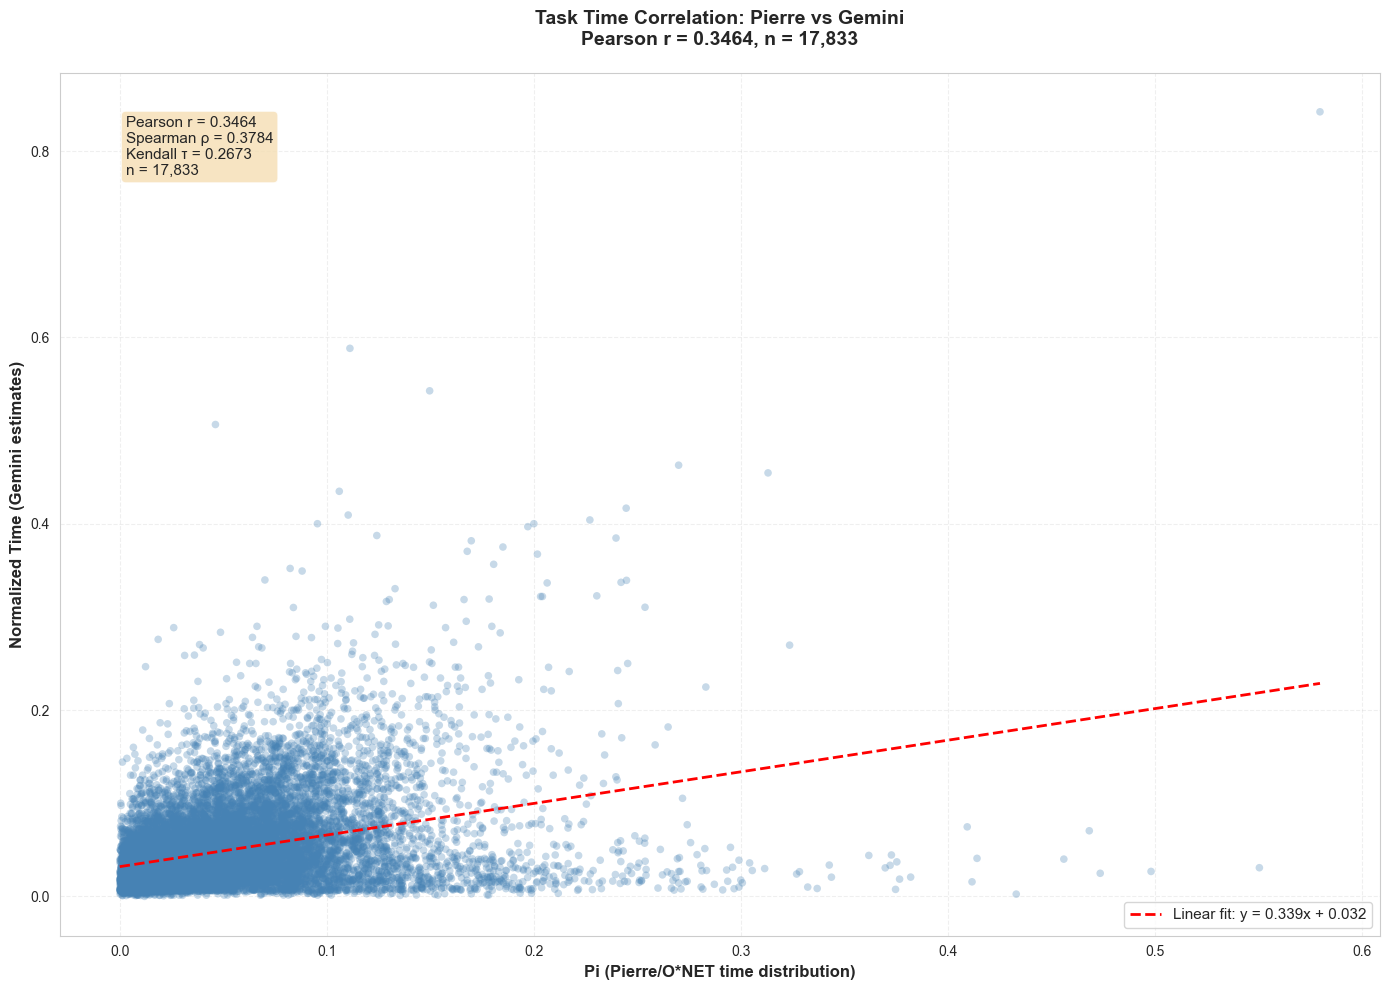

Hexbin plot saved to: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Time/correlation_hexbin.png


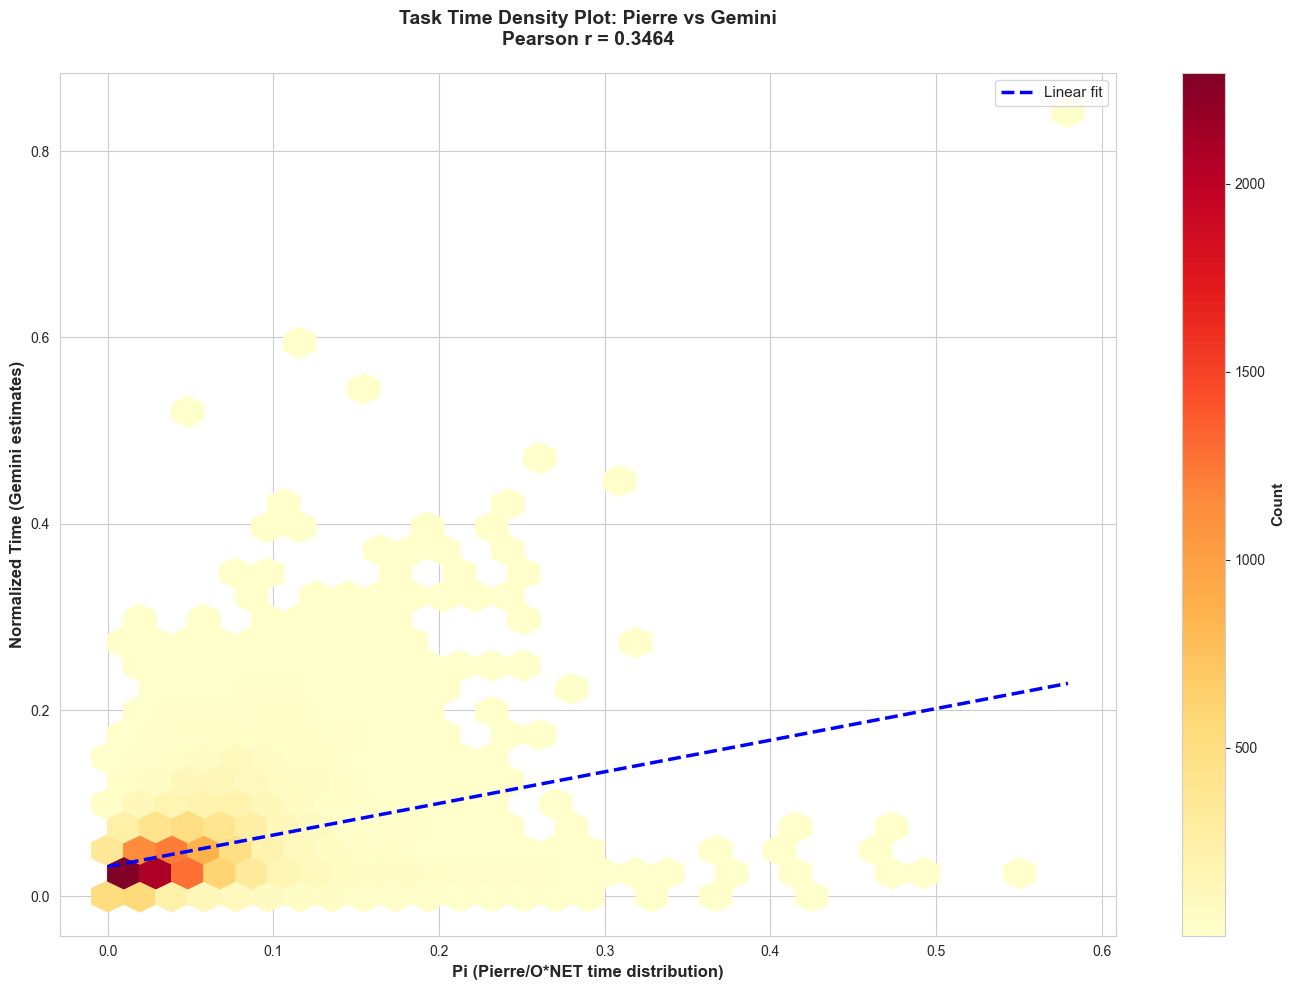

Distribution plot saved to: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Time/distributions_comparison.png


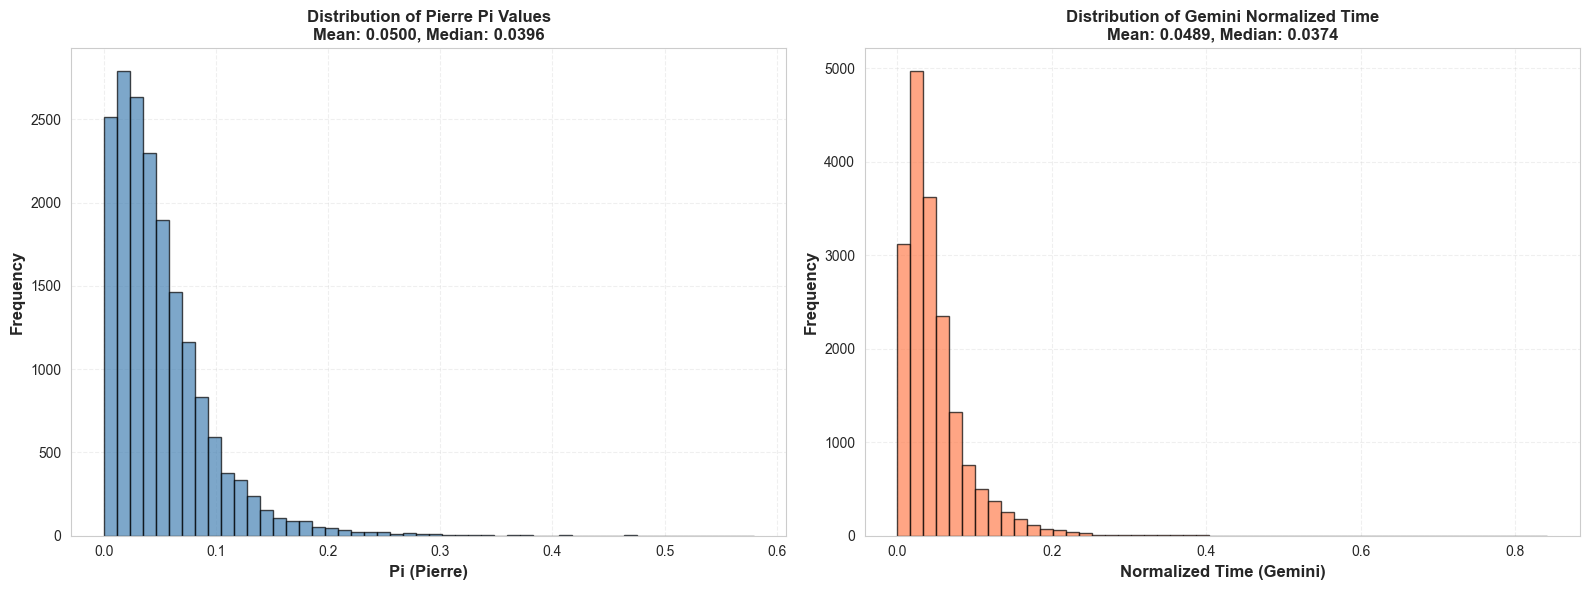

Log-log plot saved to: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Time/correlation_loglog.png


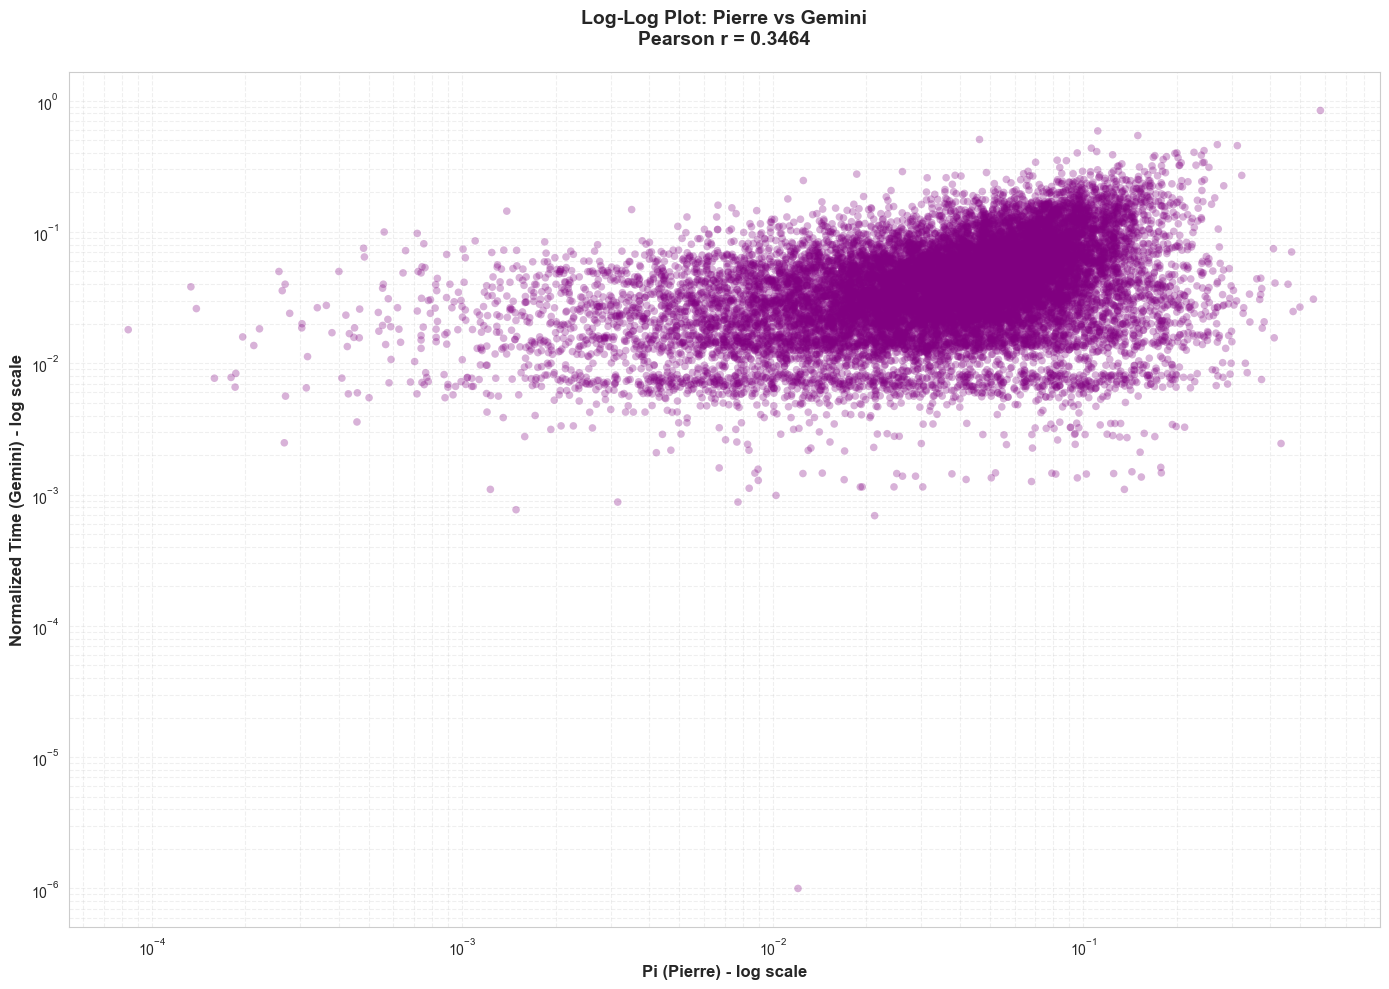

Residual plot saved to: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Time/residual_analysis.png


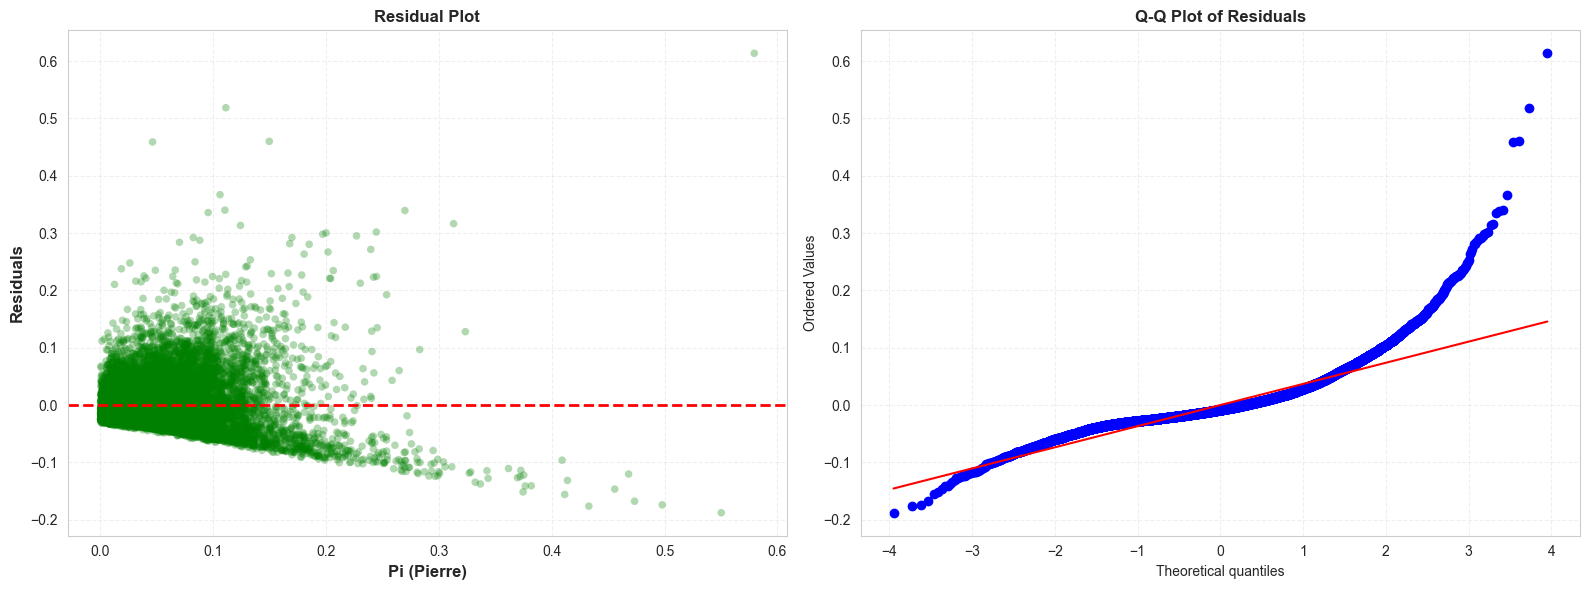


Merged dataset saved to: /Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500/Time/correlation_analysis_merged.csv
Total records: 17,833


In [ ]:
"""
Time Distribution Correlation Analysis

Compare task time estimates between:
- job_task_time_distribution_30_0.csv (pi values)
- task_time_estimates_normalized.csv (normalized_time from Gemini model)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

BASE = Path("/Users/nicobagnoli/Documents/PYTHON/Standard-Analysis-Nico/SMP500")

# Load datasets
print("Loading datasets...")
df_pierre = pd.read_csv(BASE / "data" / "job_task_time_distribution_30_0.csv")
df_gemini = pd.read_csv(BASE / "Time" / "task_time_estimates_normalized.csv")

print(f"Pierre dataset: {len(df_pierre):,} rows")
print(f"Gemini dataset: {len(df_gemini):,} rows")
print(f"\nPierre columns: {list(df_pierre.columns)}")
print(f"Gemini columns: {list(df_gemini.columns)}")

# Prepare data for merging
df_pierre_clean = df_pierre[["O*NET-SOC Code", "Task ID", "pi"]].copy()
df_pierre_clean.columns = ["occ_code", "task_id", "pi"]
df_pierre_clean["task_id"] = df_pierre_clean["task_id"].astype(str)
df_pierre_clean["occ_code"] = df_pierre_clean["occ_code"].astype(str)

df_gemini_clean = df_gemini[["occ_code", "task_id", "normalized_time"]].copy()
df_gemini_clean["task_id"] = df_gemini_clean["task_id"].astype(str)
df_gemini_clean["occ_code"] = df_gemini_clean["occ_code"].astype(str)

print(f"\nPierre unique tasks: {df_pierre_clean['task_id'].nunique():,}")
print(f"Gemini unique tasks: {df_gemini_clean['task_id'].nunique():,}")

# Merge on occupation code and task ID
df_merged = pd.merge(
    df_pierre_clean,
    df_gemini_clean,
    on=["occ_code", "task_id"],
    how="inner"
)

print(f"\nMerged dataset: {len(df_merged):,} rows")
print(f"Unique occupations: {df_merged['occ_code'].nunique():,}")
print(f"Unique tasks: {df_merged['task_id'].nunique():,}")

# Remove any NaN values
df_merged = df_merged.dropna(subset=["pi", "normalized_time"])
print(f"After removing NaN: {len(df_merged):,} rows\n")

# Calculate correlation statistics
pearson_r, pearson_p = stats.pearsonr(df_merged["pi"], df_merged["normalized_time"])
spearman_r, spearman_p = stats.spearmanr(df_merged["pi"], df_merged["normalized_time"])
kendall_tau, kendall_p = stats.kendalltau(df_merged["pi"], df_merged["normalized_time"])

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)
print(f"\nPearson correlation:  r = {pearson_r:.4f}, p = {pearson_p:.2e}")
print(f"Spearman correlation: ρ = {spearman_r:.4f}, p = {spearman_p:.2e}")
print(f"Kendall's tau:        τ = {kendall_tau:.4f}, p = {kendall_p:.2e}")
print(f"\nSample size (n):      {len(df_merged):,}")
print("=" * 60)

# Descriptive statistics
print("\n\nDescriptive Statistics:")
print("\nPierre (pi):")
print(df_merged["pi"].describe())
print("\nGemini (normalized_time):")
print(df_merged["normalized_time"].describe())

# Create scatter plot with regression line
fig, ax = plt.subplots(figsize=(14, 10))

# Create scatter plot with transparency
ax.scatter(df_merged["pi"], df_merged["normalized_time"], 
           alpha=0.3, s=30, color='steelblue', edgecolors='none')

# Add regression line
z = np.polyfit(df_merged["pi"], df_merged["normalized_time"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_merged["pi"].min(), df_merged["pi"].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Linear fit: y = {z[0]:.3f}x + {z[1]:.3f}')

# Add labels and title
ax.set_xlabel("Pi (Pierre/O*NET time distribution)", fontsize=12, fontweight='bold')
ax.set_ylabel("Normalized Time (Gemini estimates)", fontsize=12, fontweight='bold')
ax.set_title(f"Task Time Correlation: Pierre vs Gemini\nPearson r = {pearson_r:.4f}, n = {len(df_merged):,}", 
             fontsize=14, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add correlation text box
textstr = f'Pearson r = {pearson_r:.4f}\nSpearman ρ = {spearman_r:.4f}\nKendall τ = {kendall_tau:.4f}\nn = {len(df_merged):,}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
#plt.savefig(BASE / "Time" / "correlation_scatter.png", dpi=300, bbox_inches='tight')
print(f"\nScatter plot saved to: {BASE / 'Time' / 'correlation_scatter.png'}")
plt.show()

# Create hexbin plot for density visualization
fig, ax = plt.subplots(figsize=(14, 10))

hexbin = ax.hexbin(df_merged["pi"], df_merged["normalized_time"], 
                   gridsize=30, cmap='YlOrRd', mincnt=1)

ax.set_xlabel("Pi (Pierre/O*NET time distribution)", fontsize=12, fontweight='bold')
ax.set_ylabel("Normalized Time (Gemini estimates)", fontsize=12, fontweight='bold')
ax.set_title(f"Task Time Density Plot: Pierre vs Gemini\nPearson r = {pearson_r:.4f}", 
             fontsize=14, fontweight='bold', pad=20)

# Add colorbar
cb = plt.colorbar(hexbin, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Add regression line
ax.plot(x_line, p(x_line), "b--", linewidth=2.5, label=f'Linear fit')

ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
#plt.savefig(BASE / "Time" / "correlation_hexbin.png", dpi=300, bbox_inches='tight')
print(f"Hexbin plot saved to: {BASE / 'Time' / 'correlation_hexbin.png'}")
plt.show()

# Create distribution comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pierre distribution
axes[0].hist(df_merged["pi"], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel("Pi (Pierre)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Frequency", fontsize=12, fontweight='bold')
axes[0].set_title(f"Distribution of Pierre Pi Values\nMean: {df_merged['pi'].mean():.4f}, Median: {df_merged['pi'].median():.4f}", 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Gemini distribution
axes[1].hist(df_merged["normalized_time"], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel("Normalized Time (Gemini)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Frequency", fontsize=12, fontweight='bold')
axes[1].set_title(f"Distribution of Gemini Normalized Time\nMean: {df_merged['normalized_time'].mean():.4f}, Median: {df_merged['normalized_time'].median():.4f}", 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
#plt.savefig(BASE / "Time" / "distributions_comparison.png", dpi=300, bbox_inches='tight')
print(f"Distribution plot saved to: {BASE / 'Time' / 'distributions_comparison.png'}")
plt.show()

# Log-log scatter plot
epsilon = 1e-6

fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(df_merged["pi"] + epsilon, df_merged["normalized_time"] + epsilon, 
           alpha=0.3, s=30, color='purple', edgecolors='none')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Pi (Pierre) - log scale", fontsize=12, fontweight='bold')
ax.set_ylabel("Normalized Time (Gemini) - log scale", fontsize=12, fontweight='bold')
ax.set_title(f"Log-Log Plot: Pierre vs Gemini\nPearson r = {pearson_r:.4f}", 
             fontsize=14, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, linestyle='--', which='both')

plt.tight_layout()
#plt.savefig(BASE / "Time" / "correlation_loglog.png", dpi=300, bbox_inches='tight')
print(f"Log-log plot saved to: {BASE / 'Time' / 'correlation_loglog.png'}")
plt.show()

# Calculate residuals and create residual plot
predicted = p(df_merged["pi"])
residuals = df_merged["normalized_time"] - predicted

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residual plot
axes[0].scatter(df_merged["pi"], residuals, alpha=0.3, s=30, color='green', edgecolors='none')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel("Pi (Pierre)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Residuals", fontsize=12, fontweight='bold')
axes[0].set_title("Residual Plot", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Q-Q plot for residuals
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
#plt.savefig(BASE / "Time" / "residual_analysis.png", dpi=300, bbox_inches='tight')
print(f"Residual plot saved to: {BASE / 'Time' / 'residual_analysis.png'}")
plt.show()

# Save merged dataset for further analysis
output_path = BASE / "Time" / "correlation_analysis_merged.csv"
df_merged.to_csv(output_path, index=False)
print(f"\nMerged dataset saved to: {output_path}")
print(f"Total records: {len(df_merged):,}")
